In [2]:
import pandas as pd
import numpy as np

In [3]:
ruta = "../data/raw/"

df_sal = pd.read_csv(ruta + "sales.csv", index_col=0)
df_cs  = pd.read_csv(ruta + "customer_sociodemographics.csv", index_col=0)
df_cca = pd.read_csv(ruta + "customer_commercial_activity.csv", index_col=0)
df_cp  = pd.read_csv(ruta + "customer_products.csv", index_col=0)
df_prd = pd.read_csv(ruta + "product_description.csv", index_col=0)

In [4]:
# 1. Normalizar la columna temporal a periodo mensual
for d in (df_cs, df_cca, df_cp):
    d["mes"] = pd.to_datetime(d["pk_partition"]).dt.to_period("M")
df_sal["mes"] = pd.to_datetime(df_sal["month_sale"]).dt.to_period("M")

ultimo_mes = df_cca["mes"].max()
print("Último mes disponible:", ultimo_mes)

Último mes disponible: 2019-05


In [5]:
#2. Foto del ultimo mes: variable de estado del cliente en el último mes disponible
cs_ult = df_cs[df_cs["mes"] == ultimo_mes].drop(columns=["pk_partition", "mes"])
cca_ult = df_cca[df_cca["mes"] == ultimo_mes].drop(columns=["pk_partition", "mes"])
cp_ult  = df_cp[df_cp["mes"] == ultimo_mes].drop(columns=["pk_partition", "mes"])

foto = (cca_ult
        .merge(cs_ult, on="pk_cid", how="inner")
        .merge(cp_ult, on="pk_cid", how="inner"))

print("Clientes en la foto:", foto["pk_cid"].nunique(), "| filas:", len(foto))

Clientes en la foto: 442995 | filas: 442995


In [6]:
# 3. Historico variable de comportamiento del cliente: variable de estado del cliente en todos los meses disponibles

# Antigüedad del cliente: numero de meses que se encuentra en el sistema
primer_mes = df_cca.groupby("pk_cid")["mes"].min()
antiguedad = ((ultimo_mes - primer_mes).apply(lambda x: x.n) + 1).rename("antiguedad_meses")

# Meses en los que el cliente estuvo activo
meses_activo = df_cca.groupby("pk_cid")["active_customer"].sum().rename("meses_activo")

# Compras y margen acumulado en todo el periodo
ventas = (df_sal.groupby("cid")
          .agg(n_compras=("pk_sale", "count"),
               margen_total=("net_margin", "sum"))
          .rename_axis("pk_cid"))

# Meses distintos con al menos una compra
meses_con_compra = df_sal.groupby("cid")["mes"].nunique().rename("meses_con_compra").rename_axis("pk_cid")



In [7]:
# 4. Unir foto + histórico
df_clientes = (foto
               .merge(antiguedad, on="pk_cid", how="left")
               .merge(meses_activo, on="pk_cid", how="left")
               .merge(ventas, on="pk_cid", how="left")
               .merge(meses_con_compra, on="pk_cid", how="left"))


In [8]:
# Un cliente sin ventas en el periodo tiene 0 compras y 0 margen, no NaN
for c in ["n_compras", "margen_total", "meses_con_compra"]:
    df_clientes[c] = df_clientes[c].fillna(0)

In [9]:
# 5. Verificar
print("\nFilas:", len(df_clientes), "| clientes únicos:", df_clientes["pk_cid"].nunique())
print("Columnas:", df_clientes.shape[1])
print("\nNulos por columna:")
print(df_clientes.isnull().sum()[df_clientes.isnull().sum() > 0])
print("\nClientes con alguna compra en el periodo:",
      (df_clientes["n_compras"] > 0).sum(),
      f"({(df_clientes['n_compras'] > 0).mean():.1%})")
df_clientes.head()


Filas: 442995 | clientes únicos: 442995
Columnas: 31

Nulos por columna:
entry_channel      4509
segment            4616
region_code         162
gender                2
salary           149527
dtype: int64

Clientes con alguna compra en el periodo: 149550 (33.8%)


,pk_cid,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,...,payroll_account,emc_account,debit_card,em_account_p,em_acount,antiguedad_meses,meses_activo,n_compras,margen_total,meses_con_compra
0,657826,2015-05,013,1.0,02 - PARTICULARES,ES,25.0,H,44,N,...,0,0,0,0,1,17,17.0,0.0,0.0,0.0
1,657817,2019-05,NaN,0.0,NaN,ES,8.0,V,32,N,...,0,0,0,0,0,1,0.0,0.0,0.0,0.0
2,657986,2016-02,KAF,1.0,02 - PARTICULARES,ES,41.0,H,39,N,...,1,1,1,0,0,17,17.0,1.0,64.5,1.0
3,657905,2017-02,KAT,1.0,01 - TOP,ES,28.0,H,85,N,...,0,0,0,0,1,17,17.0,0.0,0.0,0.0
4,657336,2019-03,KAT,1.0,02 - PARTICULARES,ES,28.0,V,38,N,...,0,0,0,0,1,3,2.0,1.0,68.3,1.0


In [10]:
df_clientes.head(0)

,pk_cid,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,...,payroll_account,emc_account,debit_card,em_account_p,em_acount,antiguedad_meses,meses_activo,n_compras,margen_total,meses_con_compra


Ralmente todos los clientes tienen compra y generan beneficio?

In [11]:
sin_compras = df_clientes[df_clientes["n_compras"] == 0]

print("Sin compras y en la base desde el inicio (17 meses):",
      (sin_compras["antiguedad_meses"] == 17).sum())
print("Sin compras y entraron durante el periodo:",
      (sin_compras["antiguedad_meses"] < 17).sum())

# ¿Cuántos productos tienen los que entraron durante el periodo sin compras?
cols_prod = [c for c in df_cp.columns if c not in ("pk_cid", "pk_partition", "mes")]
nuevos_sin_compra = sin_compras[sin_compras["antiguedad_meses"] < 17]
print(nuevos_sin_compra[cols_prod].sum(axis=1).value_counts().sort_index())

Sin compras y en la base desde el inicio (17 meses): 197833
Sin compras y entraron durante el periodo: 95612
0.0    95612
Name: count, dtype: int64


In [12]:
df_clientes["n_productos"] = df_clientes[cols_prod].sum(axis=1)
print(df_clientes["n_productos"].value_counts().sort_index())
print("\nClientes con 0 productos:", (df_clientes["n_productos"] == 0).sum(),
      f"({(df_clientes['n_productos'] == 0).mean():.1%})")

n_productos
0.0    111407
1.0    268286
2.0     38714
3.0     11502
4.0      8479
5.0      3342
6.0      1038
7.0       194
8.0        31
9.0         2
Name: count, dtype: int64

Clientes con 0 productos: 111407 (25.1%)


In [13]:
sin_prod = df_clientes[df_clientes["n_productos"] == 0]
print(sin_prod["active_customer"].value_counts())
print(sin_prod["segment"].value_counts(dropna=False))
print(sin_prod["entry_channel"].value_counts(dropna=False).head(5))

active_customer
0.0    106525
1.0      4882
Name: count, dtype: int64
segment
03 - UNIVERSITARIO    60734
02 - PARTICULARES     47184
NaN                    3010
01 - TOP                479
Name: count, dtype: int64
entry_channel
KHE    37719
KFC    21467
KHQ    20436
KHM     8759
KAT     6404
Name: count, dtype: int64


Nos damos cuenta que hay un alto % de clientes que solo estan registrado y que no han realizado niinguna compra, por eso los eliminamos de la tabla

In [14]:
# Nueva tabla con clientes que tienen al menos un producto
cols_prod = [c for c in df_cp.columns if c not in ("pk_cid", "pk_partition", "mes")]
df_clientes["n_productos"] = df_clientes[cols_prod].sum(axis=1)

df_sin_producto = df_clientes[df_clientes["n_productos"] == 0].copy()
df_con_producto = df_clientes[df_clientes["n_productos"] >= 1].copy()

print("Sin producto:", len(df_sin_producto))
print("Con producto:", len(df_con_producto))
print("Total:       ", len(df_sin_producto) + len(df_con_producto), "(debe ser 442995)")

#Restablecemos el index
df_con_producto = df_con_producto.reset_index(drop=True)

Sin producto: 111407
Con producto: 331588
Total:        442995 (debe ser 442995)


Nos quedamos con la csv Con Producto

In [15]:
df_con_producto.head()

,pk_cid,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,...,emc_account,debit_card,em_account_p,em_acount,antiguedad_meses,meses_activo,n_compras,margen_total,meses_con_compra,n_productos
0,657826,2015-05,013,1.0,02 - PARTICULARES,ES,25.0,H,44,N,...,0,0,0,1,17,17.0,0.0,0.0,0.0,1.0
1,657986,2016-02,KAF,1.0,02 - PARTICULARES,ES,41.0,H,39,N,...,1,1,0,0,17,17.0,1.0,64.5,1.0,6.0
2,657905,2017-02,KAT,1.0,01 - TOP,ES,28.0,H,85,N,...,0,0,0,1,17,17.0,0.0,0.0,0.0,2.0
3,657336,2019-03,KAT,1.0,02 - PARTICULARES,ES,28.0,V,38,N,...,0,0,0,1,3,2.0,1.0,68.3,1.0,1.0
4,658184,2015-05,KAT,1.0,02 - PARTICULARES,ES,28.0,V,42,N,...,1,1,0,0,17,17.0,1.0,54.1,1.0,6.0


In [16]:
df_con_producto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331588 entries, 0 to 331587
Data columns (total 32 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   pk_cid              331588 non-null  int64  
 1   entry_date          331588 non-null  object 
 2   entry_channel       330009 non-null  object 
 3   active_customer     331588 non-null  float64
 4   segment             329982 non-null  object 
 5   country_id          331588 non-null  object 
 6   region_code         331466 non-null  float64
 7   gender              331586 non-null  object 
 8   age                 331588 non-null  int64  
 9   deceased            331588 non-null  object 
 10  salary              227533 non-null  float64
 11  short_term_deposit  331588 non-null  int64  
 12  loans               331588 non-null  int64  
 13  mortgage            331588 non-null  int64  
 14  funds               331588 non-null  int64  
 15  securities          331588 non-nul

In [17]:
nulos = df_con_producto.isnull().sum()
print("Columnas con nulos:\n", nulos[nulos > 0])

Columnas con nulos:
 entry_channel      1579
segment            1606
region_code         122
gender                2
salary           104055
dtype: int64


In [18]:
# gender: moda
df_con_producto["gender"] = df_con_producto["gender"].fillna(df_con_producto["gender"].mode()[0])

# region_code: moda para España, 0 para extranjeros
moda_region = df_con_producto.loc[df_con_producto["country_id"] == "ES", "region_code"].mode()[0]
mask_es  = df_con_producto["region_code"].isnull() & (df_con_producto["country_id"] == "ES")
mask_ext = df_con_producto["region_code"].isnull() & (df_con_producto["country_id"] != "ES")
df_con_producto.loc[mask_es,  "region_code"] = moda_region
df_con_producto.loc[mask_ext, "region_code"] = 0.0

# entry_channel y segment: los tres casos
# Caso 1: falta entry_channel pero hay segment → moda del canal dentro de ese segment
moda_canal_por_seg = df_con_producto.groupby("segment")["entry_channel"].agg(lambda s: s.mode()[0])
mask1 = df_con_producto["entry_channel"].isnull() & df_con_producto["segment"].notnull()
df_con_producto.loc[mask1, "entry_channel"] = df_con_producto.loc[mask1, "segment"].map(moda_canal_por_seg)

# Caso 2: falta segment pero hay entry_channel → moda del segment dentro de ese canal
moda_seg_por_canal = df_con_producto.groupby("entry_channel")["segment"].agg(lambda s: s.mode()[0])
mask2 = df_con_producto["segment"].isnull() & df_con_producto["entry_channel"].notnull()
df_con_producto.loc[mask2, "segment"] = df_con_producto.loc[mask2, "entry_channel"].map(moda_seg_por_canal)

# Caso 3: faltan los dos → Desconocido
mask3 = df_con_producto["entry_channel"].isnull() & df_con_producto["segment"].isnull()
df_con_producto.loc[mask3, ["entry_channel", "segment"]] = "Desconocido"

print("Caso 1:", mask1.sum(), "| Caso 2:", mask2.sum(), "| Caso 3:", mask3.sum())
print("\nNulos restantes:")
print(df_con_producto.isnull().sum()[df_con_producto.isnull().sum() > 0])

Caso 1: 4 | Caso 2: 31 | Caso 3: 1575

Nulos restantes:
salary    104055
dtype: int64


In [19]:
print("Nulos de salary:", df_con_producto["salary"].isnull().sum(),
      f"({df_con_producto['salary'].isnull().mean():.1%})")

print("\nProporción de salary nulo por segment:")
print(df_con_producto.groupby("segment")["salary"].apply(lambda s: s.isnull().mean()).round(3))

df_con_producto["tramo_edad"] = pd.cut(df_con_producto["age"],
                                        bins=[0, 25, 35, 45, 55, 65, 120],
                                        labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"])
print("\nProporción de salary nulo por tramo de edad:")
print(df_con_producto.groupby("tramo_edad", observed=True)["salary"].apply(lambda s: s.isnull().mean()).round(3))

print("\nDescriptivos de salary (donde existe):")
print(df_con_producto["salary"].describe().round(0))
print("Percentil 99:", round(df_con_producto["salary"].quantile(0.99)))
print("Máximo:", round(df_con_producto["salary"].max()))

Nulos de salary: 104055 (31.4%)

Proporción de salary nulo por segment:
segment
01 - TOP              0.350
02 - PARTICULARES     0.347
03 - UNIVERSITARIO    0.293
Desconocido           0.996
Name: salary, dtype: float64

Proporción de salary nulo por tramo de edad:
tramo_edad
<25      0.312
25-34    0.294
35-44    0.339
45-54    0.341
55-64    0.344
65+      0.319
Name: salary, dtype: float64

Descriptivos de salary (donde existe):
count      227533.0
mean       112607.0
std        188884.0
min          1203.0
25%         60851.0
50%         87184.0
75%        128195.0
max      28894396.0
Name: salary, dtype: float64
Percentil 99: 465916
Máximo: 28894396


In [20]:
# Marcar qué clientes tenían salary nulo antes de imputar
df_con_producto["salary_imputado"] = df_con_producto["salary"].isnull().astype(int)

# Mediana de salary por segment × tramo_edad
mediana_salary = df_con_producto.groupby(["segment", "tramo_edad"], observed=True)["salary"].transform("median")
df_con_producto["salary"] = df_con_producto["salary"].fillna(mediana_salary)

# Si alguna combinación no tenía ningún salario real, cae a la mediana global
df_con_producto["salary"] = df_con_producto["salary"].fillna(df_con_producto["salary"].median())

print("Clientes imputados:", df_con_producto["salary_imputado"].sum())
print("Nulos restantes:")
print(df_con_producto.isnull().sum()[df_con_producto.isnull().sum() > 0])

Clientes imputados: 104055
Nulos restantes:
Series([], dtype: int64)


DECIDIR que variables entran en el K-means

In [21]:
#Conprobacion de la varianza en las varaibles de productos para saber si entra o no en el K-Means. Si no hay varianza, no aporta información y no se debe incluir.
presencia = df_con_producto[cols_prod].sum().sort_values(ascending=False)
print(pd.DataFrame({"clientes": presencia.astype(int),
                    "pct": (presencia / len(df_con_producto) * 100).round(2)}))

                    clientes    pct
em_acount             296380  89.38
debit_card             43261  13.05
payroll_account        26529   8.00
emc_account            24751   7.46
pension_plan           17353   5.23
payroll                16333   4.93
long_term_deposit       6129   1.85
credit_card             4801   1.45
securities              1789   0.54
funds                   1315   0.40
loans                     30   0.01
mortgage                  23   0.01
short_term_deposit         2   0.00
em_account_p               2   0.00
em_account_pp              0   0.00


In [22]:
# Variables que entran en el K-Means, agrupadas por tipo
vars_numericas = ["age", "salary", "n_productos", "antiguedad_meses", "n_compras", "margen_total"]
vars_producto  = ["em_acount", "debit_card", "payroll_account", "emc_account", "pension_plan",
                  "payroll", "long_term_deposit", "credit_card", "securities", "funds"]
vars_categoricas = ["segment"]

# Tabla de features: solo las variables seleccionadas + identificador
df_features = df_con_producto[["pk_cid"] + vars_numericas + vars_producto + vars_categoricas].copy()
print(df_features.shape)
df_features.head()

(331588, 18)


,pk_cid,age,salary,n_productos,antiguedad_meses,n_compras,margen_total,em_acount,debit_card,payroll_account,emc_account,pension_plan,payroll,long_term_deposit,credit_card,securities,funds,segment
0,657826,44,54493.380,1.0,17,0.0,0.0,1,0,0,0,0.0,0.0,0,0,0,0,02 - PARTICULARES
1,657986,39,100993.170,6.0,17,1.0,64.5,0,1,1,1,1.0,1.0,0,1,0,0,02 - PARTICULARES
2,657905,85,154059.090,2.0,17,0.0,0.0,1,0,0,0,0.0,0.0,1,0,0,0,01 - TOP
3,657336,38,86516.295,1.0,3,1.0,68.3,1,0,0,0,0.0,0.0,0,0,0,0,02 - PARTICULARES
4,658184,42,183036.720,6.0,17,1.0,54.1,0,1,1,1,1.0,1.0,0,1,0,0,02 - PARTICULARES


In [23]:
# ── Correlación entre las variables numéricas ────────────────────────────
# Buscamos pares por encima de 0.7-0.8 en valor absoluto: indicarían redundancia
print(df_features[vars_numericas].corr().round(2))

                   age  salary  n_productos  antiguedad_meses  n_compras  \
age               1.00    0.03         0.31             -0.05       0.22   
salary            0.03    1.00         0.02              0.04      -0.00   
n_productos       0.31    0.02         1.00              0.02       0.54   
antiguedad_meses -0.05    0.04         0.02              1.00      -0.45   
n_compras         0.22   -0.00         0.54             -0.45       1.00   
margen_total      0.13    0.01         0.50             -0.05       0.74   

                  margen_total  
age                       0.13  
salary                    0.01  
n_productos               0.50  
antiguedad_meses         -0.05  
n_compras                 0.74  
margen_total              1.00  


preprocesado: logaritmo, one‑hot y escalado.

simetría por encima de 2‑3 significa cola larga hacia la derecha,

In [24]:
# Asimetría de las variables numéricas: decide cuáles llevan logaritmo
# Skew ≈ 0 → simétrica. Skew > 2-3 → cola larga, candidata a logaritmo
print(df_features[vars_numericas].skew().round(2))
print("\nMínimos (el logaritmo necesita valores >= 0):")
print(df_features[vars_numericas].min())

age                  1.91
salary              74.30
n_productos          3.12
antiguedad_meses    -1.31
n_compras            2.23
margen_total         4.50
dtype: float64

Mínimos (el logaritmo necesita valores >= 0):
age                    3.00
salary              1202.73
n_productos            1.00
antiguedad_meses       1.00
n_compras              0.00
margen_total           0.00
dtype: float64


In [25]:
# Transformación logarítmica de las variables con cola larga
# log1p = log(1 + x): convierte el 0 en 0 y acepta ceros
vars_log = ["salary", "n_productos", "n_compras", "margen_total"]

df_features_prep = df_features.copy()
for col in vars_log:
    df_features_prep[col] = np.log1p(df_features_prep[col])

print("Asimetría después del logaritmo:")
print(df_features_prep[vars_numericas].skew().round(2))

Asimetría después del logaritmo:
age                 1.91
salary              0.66
n_productos         2.37
antiguedad_meses   -1.31
n_compras           1.01
margen_total        0.84
dtype: float64


In [26]:
from sklearn.preprocessing import MinMaxScaler

# One-hot de segment: una columna 0/1 por cada categoría 
df_features_prep = pd.get_dummies(df_features_prep, columns=["segment"], prefix="seg", dtype=int)

# Separar el identificador: no entra en el K-Means
ids = df_features_prep["pk_cid"]
X = df_features_prep.drop(columns=["pk_cid"])

# Escalado MinMax: todas las columnas al rango 0-1
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("Dimensión de X_scaled:", X_scaled.shape)
print("\nColumnas:", list(X_scaled.columns))
print("\nRango de cada columna (debe ser 0 a 1):")
print(X_scaled.describe().loc[["min", "max"]].T)

Dimensión de X_scaled: (331588, 20)

Columnas: ['age', 'salary', 'n_productos', 'antiguedad_meses', 'n_compras', 'margen_total', 'em_acount', 'debit_card', 'payroll_account', 'emc_account', 'pension_plan', 'payroll', 'long_term_deposit', 'credit_card', 'securities', 'funds', 'seg_01 - TOP', 'seg_02 - PARTICULARES', 'seg_03 - UNIVERSITARIO', 'seg_Desconocido']

Rango de cada columna (debe ser 0 a 1):
                        min  max
age                     0.0  1.0
salary                  0.0  1.0
n_productos             0.0  1.0
antiguedad_meses        0.0  1.0
n_compras               0.0  1.0
margen_total            0.0  1.0
em_acount               0.0  1.0
debit_card              0.0  1.0
payroll_account         0.0  1.0
emc_account             0.0  1.0
pension_plan            0.0  1.0
payroll                 0.0  1.0
long_term_deposit       0.0  1.0
credit_card             0.0  1.0
securities              0.0  1.0
funds                   0.0  1.0
seg_01 - TOP            0.0  1.0
seg

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Muestra para silhouette (el cálculo completo sería demasiado lento) ──
muestra = X_scaled.sample(n=30000, random_state=42)

# ── Probar k de 3 a 12 ───────────────────────────────────────────────────
resultados = []
for k in range(3, 13):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = km.fit_predict(X_scaled)
    sil = silhouette_score(muestra, km.predict(muestra))
    resultados.append({"k": k, "inercia": round(km.inertia_, 0), "silhouette": round(sil, 4)})
    print(f"k={k:2d} | inercia={km.inertia_:>12,.0f} | silhouette={sil:.4f}")

df_k = pd.DataFrame(resultados)

k= 3 | inercia=     170,831 | silhouette=0.5850
k= 4 | inercia=     148,015 | silhouette=0.5740
k= 5 | inercia=     130,912 | silhouette=0.5878
k= 6 | inercia=     117,731 | silhouette=0.5963
k= 7 | inercia=     105,422 | silhouette=0.6088
k= 8 | inercia=      94,839 | silhouette=0.6236
k= 9 | inercia=      86,600 | silhouette=0.6301
k=10 | inercia=      79,643 | silhouette=0.6283
k=11 | inercia=      71,802 | silhouette=0.6608
k=12 | inercia=      68,972 | silhouette=0.6593


In [28]:
# K-Means final con k=7
kmeans_final = KMeans(n_clusters=7, n_init=10, random_state=42)
df_con_producto["grupo"] = kmeans_final.fit_predict(X_scaled) + 1   # grupos 1 a 7

# Tamaño de cada grupo
tamanos = df_con_producto["grupo"].value_counts().sort_index()
print(pd.DataFrame({"clientes": tamanos,
                    "pct": (tamanos / len(df_con_producto) * 100).round(1)}))

       clientes   pct
grupo                
1        147825  44.6
2         62923  19.0
3         10215   3.1
4         68506  20.7
5         16755   5.1
6          6106   1.8
7         19258   5.8


In [29]:
# ── Perfil numérico de cada grupo (valores reales) ───────────────────────
perfil_num = df_con_producto.groupby("grupo").agg(
    clientes=("pk_cid", "count"),
    edad_media=("age", "mean"),
    renta_mediana=("salary", "median"),
    antiguedad_media=("antiguedad_meses", "mean"),
    n_productos_medio=("n_productos", "mean"),
    n_compras_medio=("n_compras", "mean"),
    margen_medio=("margen_total", "mean"),
    pct_activos=("active_customer", "mean"),
    pct_mujeres=("gender", lambda s: (s == "V").mean() if "V" in s.values else (s == "F").mean())
).round(2)
print(perfil_num)

# ── Presencia de cada producto en cada grupo (% de clientes que lo tienen) ─
perfil_prod = (df_con_producto.groupby("grupo")[vars_producto].mean() * 100).round(1)
print("\n", perfil_prod)

# ── Distribución de segment dentro de cada grupo ─────────────────────────
perfil_seg = (pd.crosstab(df_con_producto["grupo"], df_con_producto["segment"], normalize="index") * 100).round(1)
print("\n", perfil_seg)

       clientes  edad_media  renta_mediana  antiguedad_media  \
grupo                                                          
1        147825       24.40       86037.96             17.00   
2         62923       43.51       86516.30             13.49   
3         10215       35.10       86516.30             14.87   
4         68506       23.05       86037.96              9.92   
5         16755       37.15       86516.30             14.42   
6          6106       54.69      122256.45             13.04   
7         19258       41.37       86516.30             13.51   

       n_productos_medio  n_compras_medio  margen_medio  pct_activos  \
grupo                                                                  
1                   1.02             0.00          0.00         0.25   
2                   1.17             0.68        164.64         0.72   
3                   1.70             2.70       3967.68         0.92   
4                   1.10             1.08        123.50        

In [30]:
from sklearn.metrics import adjusted_rand_score

# ── K-Means sin salary, mismos parámetros ────────────────────────────────
X_sin_salary = X_scaled.drop(columns=["salary"])
kmeans_sin_salary = KMeans(n_clusters=7, n_init=10, random_state=42)
grupo_sin_salary = kmeans_sin_salary.fit_predict(X_sin_salary) + 1

# ── Comparar asignaciones: ARI = 1 idénticas, 0 independientes ──────────
ari = adjusted_rand_score(df_con_producto["grupo"], grupo_sin_salary)
print(f"Adjusted Rand Index con vs sin salary: {ari:.3f}")

# ── Tabla cruzada: cómo se reparten los grupos originales en la nueva solución
print(pd.crosstab(df_con_producto["grupo"], grupo_sin_salary))

Adjusted Rand Index con vs sin salary: 0.954
col_0       1      2      3      4      5     6      7
grupo                                                 
1      147822      0      0      0      0     3      0
2           0  50243      0      0      0     0  12680
3           0     12   2302    303      0  3894   3704
4           0      0      0      0  68340    95     71
5           0      0      0  11941     17  4783     14
6         180     82    151     41    412     2   5238
7           0      0  19157     18      0     0     83


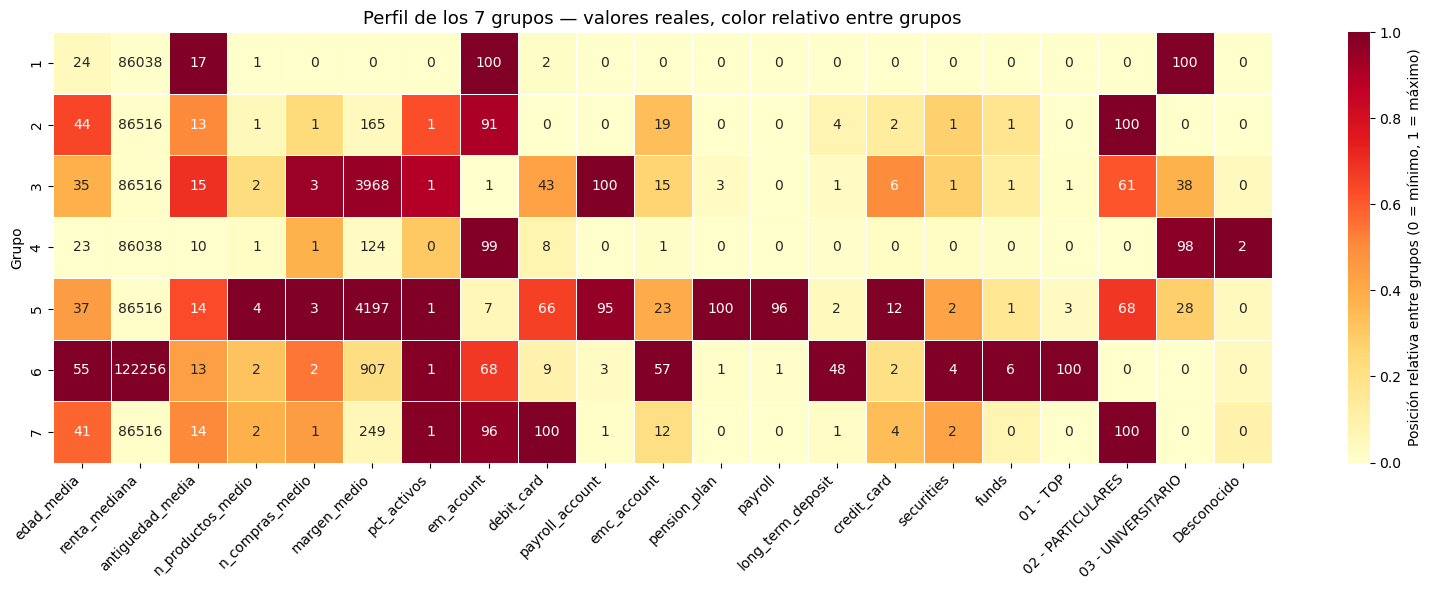

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Juntar las variables de perfil en una sola tabla ─────────────────────
perfil = pd.concat([
    perfil_num.drop(columns=["clientes", "pct_mujeres"]),
    perfil_prod,
    perfil_seg
], axis=1)

# ── Normalizar cada columna entre grupos: 0 = el grupo más bajo, 1 = el más alto
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

# ── Mapa de calor ────────────────────────────────────────────────────────
plt.figure(figsize=(16, 6))
sns.heatmap(perfil_norm, annot=perfil.round(0), fmt="g", cmap="YlOrRd",
            cbar_kws={"label": "Posición relativa entre grupos (0 = mínimo, 1 = máximo)"},
            linewidths=0.5)
plt.title("Perfil de los 7 grupos — valores reales, color relativo entre grupos", fontsize=13)
plt.ylabel("Grupo")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Sin producto (111.407 · 25%) — Se registraron pero nunca contrataron nada. No son clientes todavía; son una oportunidad de activación.

Grupo 1 · Universitarios inactivos (147.825 · 33%) — Jóvenes de 24 años con solo la cuenta básica desde antes de 2018 y ninguna contratación en 17 meses. Solo uno de cada cuatro entra en la app.

Grupo 4 · Universitarios recién llegados (68.506 · 15%) — Mismo perfil que los inactivos, pero abrieron la cuenta hace menos de un año. La mitad usa la app. Están en el momento de decidir si easyMoney les sirve para algo más.

Grupo 2 · Particulares básicos (62.923 · 14%) — Adultos de 43 años con la cuenta y poco más. Activos, pero con una relación mínima con nosotros.

Grupo 7 · Particulares con tarjeta (19.258 · 4%) — Adultos de 41 años que ya han dado el primer paso: cuenta y tarjeta de débito, casi todos activos.

Grupo 3 · Clientes de nómina (10.215 · 2%) — Entraron por la cuenta nómina en vez de por la cuenta básica, 35 años, muy activos y con un margen 25 veces mayor que el particular básico.

Grupo 5 · Nómina y pensiones (16.755 · 4%) — Los clientes más vinculados: nómina, cuenta nómina, plan de pensiones y cuatro productos de media. Aquí están prácticamente todos los planes de pensiones de la base y el margen más alto de todos.

Grupo 6 · TOP ahorradores (6.106 · 1%) — Clientes de 55 años del segmento TOP, con la renta más alta y depósitos a largo plazo. Pocos, pero cada uno vale cuatro veces más que un particular con tarjeta.

# oportunidades comerciales

Sin producto — Activación: campaña para que contraten su primer producto, empezando por la cuenta básica.

Universitarios inactivos — Reactivación: recuperar el uso de la app antes de intentar vender nada. Sin actividad no hay cross‑selling posible. Prioridad baja en presupuesto hasta ver quién responde.

Universitarios recién llegados — Acompañamiento: consolidar el hábito en los primeros meses (uso de la app, tarjeta de débito como segundo producto). Evitar que se conviertan en el grupo anterior.

Particulares básicos — Segundo producto: es el grupo más grande con capacidad real de compra. Tarjeta de débito y cuenta nómina como puerta de entrada; los que respondan pasan a perfiles de más valor.

Particulares con tarjeta — Nómina: ya han demostrado que compran; el paso natural es domiciliar la nómina, que es lo que separa a este grupo del de mayor margen.

Clientes de nómina — Plan de pensiones: tienen la nómina pero no el plan. Son el perfil más parecido al grupo 5 sin serlo todavía, y el modelo de propensión de pension_plan debería ser especialmente útil aquí.

Nómina y pensiones — Fidelización: son los clientes más valiosos y ya tienen los productos clave. El objetivo no es venderles más, es que no se vayan. Inversión y ahorro a largo plazo como complemento.

TOP ahorradores — Inversión: renta alta, edad de planificar la jubilación y ya ahorran a plazo. Fondos y valores como producto natural, con trato personalizado por el volumen que representan.

In [32]:
# ── Etiqueta del grupo Sin producto ──────────────────────────────────────
df_sin_producto["grupo"] = 0

# ── Nombres de negocio de cada grupo ─────────────────────────────────────
nombres_grupo = {
    0: "Sin producto",
    1: "Universitarios inactivos",
    2: "Particulares básicos",
    3: "Clientes de nómina",
    4: "Universitarios recién llegados",
    5: "Nómina y pensiones",
    6: "TOP ahorradores",
    7: "Particulares con tarjeta"
}

# ── Unir las dos partes ──────────────────────────────────────────────────
df_grupos = pd.concat([
    df_sin_producto[["pk_cid", "grupo"]],
    df_con_producto[["pk_cid", "grupo"]]
], ignore_index=True)
df_grupos["nombre_grupo"] = df_grupos["grupo"].map(nombres_grupo)

print("Filas:", len(df_grupos), "| clientes únicos:", df_grupos["pk_cid"].nunique())
print(df_grupos["nombre_grupo"].value_counts())

# ── Exportar ─────────────────────────────────────────────────────────────
df_grupos.to_csv("../data/processed/clientes_grupos.csv", index=False)

Filas: 442995 | clientes únicos: 442995
nombre_grupo
Universitarios inactivos          147825
Sin producto                      111407
Universitarios recién llegados     68506
Particulares básicos               62923
Particulares con tarjeta           19258
Nómina y pensiones                 16755
Clientes de nómina                 10215
TOP ahorradores                     6106
Name: count, dtype: int64


## 9. Grupo a cierre de abril (para la Tarea 4)

La Tarea 4 cruza los grupos con la validación de la Tarea 2, que mide compras de mayo. Para evitar fuga temporal, el grupo de cada cliente debe asignarse con datos de abril. Se reutilizan el scaler y el K-Means ya entrenados (predict, sin reentrenar).

In [33]:
# ── Grupo de cada cliente a cierre de ABRIL 2019 ─────────────────────────
# Mismas variables, mismas transformaciones, mismo scaler y mismo K-Means
# (predict, sin reentrenar). Permite cruzar la segmentación con la validación
# de la Tarea 2 (compras de mayo) sin fuga temporal: el grupo se asigna con
# información anterior al mes en que se mide la compra.

mes_abril = ultimo_mes - 1

def foto_del_mes(mes):
    cs  = df_cs[df_cs["mes"] == mes].drop(columns=["pk_partition", "mes"])
    cca = df_cca[df_cca["mes"] == mes].drop(columns=["pk_partition", "mes"])
    cp  = df_cp[df_cp["mes"] == mes].drop(columns=["pk_partition", "mes"])
    f = cca.merge(cs, on="pk_cid", how="inner").merge(cp, on="pk_cid", how="inner")

    # Histórico acumulado SOLO hasta ese mes (una compra de mayo no cuenta en abril)
    primer_mes = df_cca[df_cca["mes"] <= mes].groupby("pk_cid")["mes"].min()
    antig = ((mes - primer_mes).apply(lambda x: x.n) + 1).rename("antiguedad_meses")
    ventas_hasta = (df_sal[df_sal["mes"] <= mes].groupby("cid")
                    .agg(n_compras=("pk_sale", "count"), margen_total=("net_margin", "sum"))
                    .rename_axis("pk_cid"))
    f = f.merge(antig, on="pk_cid", how="left").merge(ventas_hasta, on="pk_cid", how="left")
    f[["n_compras", "margen_total"]] = f[["n_compras", "margen_total"]].fillna(0)
    f["n_productos"] = f[cols_prod].sum(axis=1)
    return f

foto_abr = foto_del_mes(mes_abril)
print("Mes:", mes_abril, "| clientes en abril:", len(foto_abr))

# Regla previa, igual que en mayo: sin ningún producto → grupo 0
sin_prod_abr = foto_abr.loc[foto_abr["n_productos"] == 0, ["pk_cid"]].copy()
sin_prod_abr["grupo"] = 0
con_prod_abr = foto_abr[foto_abr["n_productos"] >= 1].copy()

# Nulos con las mismas reglas que en mayo
con_prod_abr["segment"] = con_prod_abr["segment"].fillna("Desconocido")
con_prod_abr["tramo_edad"] = pd.cut(con_prod_abr["age"], bins=[0, 25, 35, 45, 55, 65, 120],
                                    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"])
tabla_mediana = (df_con_producto.groupby(["segment", "tramo_edad"], observed=True)["salary"]
                 .median().rename("salary_mediana").reset_index())
con_prod_abr = con_prod_abr.merge(tabla_mediana, on=["segment", "tramo_edad"], how="left")
con_prod_abr["salary"] = (con_prod_abr["salary"]
                          .fillna(con_prod_abr["salary_mediana"])
                          .fillna(df_con_producto["salary"].median()))

print("Sin producto:", len(sin_prod_abr), "| con producto:", len(con_prod_abr))

Mes: 2019-04 | clientes en abril: 439627
Sin producto: 110020 | con producto: 329607


In [34]:
X_abr = con_prod_abr[vars_numericas + vars_producto + vars_categoricas].copy()
for col in vars_log:
    X_abr[col] = np.log1p(X_abr[col])
X_abr = pd.get_dummies(X_abr, columns=["segment"], prefix="seg", dtype=int)
X_abr = X_abr.reindex(columns=X.columns, fill_value=0)   # mismas columnas y mismo orden que en mayo

X_abr_scaled = scaler.transform(X_abr)                    # transform, NO fit_transform
con_prod_abr["grupo"] = kmeans_final.predict(X_abr_scaled) + 1

df_grupos_abr = pd.concat([sin_prod_abr, con_prod_abr[["pk_cid", "grupo"]]], ignore_index=True)
df_grupos_abr["nombre_grupo"] = df_grupos_abr["grupo"].map(nombres_grupo)
print(df_grupos_abr["nombre_grupo"].value_counts())

# Estabilidad: de los clientes presentes en abril y mayo, ¿cuántos siguen en el mismo grupo?
comp = df_grupos_abr.merge(df_grupos, on="pk_cid", suffixes=("_abr", "_may"))
print(f"\nClientes en ambos meses: {len(comp):,} | mismo grupo: {(comp['grupo_abr'] == comp['grupo_may']).mean():.1%}")

df_grupos_abr.to_csv("../data/processed/clientes_grupos_abril.csv", index=False)

/Users/sandramartinez/miniconda3/envs/python3.9/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


nombre_grupo
Universitarios inactivos          148478
Sin producto                      110020
Universitarios recién llegados     68543
Particulares básicos               62179
Particulares con tarjeta           18701
Nómina y pensiones                 15629
Clientes de nómina                 10180
TOP ahorradores                     5897
Name: count, dtype: int64

Clientes en ambos meses: 438,407 | mismo grupo: 96.6%
